In [1]:
import sys
sys.path.append("../")
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl

from brokenaxes import brokenaxes
import qutip as qt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter


colors = [
    "#1f77b4",  # Blue
    "#ff7f0e",  # Orange
    "#2ca02c",  # Green
    "#d62728",  # Red
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Yellow-green
    "#17becf",  # Cyan
]

linewidth = 0.4
tick_length = 1
tick_width = linewidth
SMALL_SIZE = 5 # 7 # 5
Fontsize_legend = 5 # 4
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
DASH = (1.5, 1)

# mpl.rcParams['font.family'] = "sans-serif"
# mpl.rcParams['font.sans-serif'] = "Arial"
# plt.rcParams['mathtext.fontset'] = 'custom' # Use mathtext (default engine, simpler LaTeX support)
# plt.rcParams['mathtext.rm'] = 'Arial' # "Arial", "Helvetica" 'DejaVu Sans' 'Times New Roman'
# plt.rcParams['mathtext.it'] = 'Arial:italic'
# plt.rcParams['text.usetex'] = True
plt.rc("font", size=SMALL_SIZE)
plt.rc("axes", titlesize=SMALL_SIZE, labelsize=SMALL_SIZE)  # fontsize of the axes
plt.rc(
    ["xtick", "ytick"], labelsize=SMALL_SIZE, direction="in"
)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=SMALL_SIZE)  # fontsize of the figure title
mpl.rcParams["axes.linewidth"] = linewidth
mpl.rcParams["lines.linewidth"] = linewidth
# mpl.rcParams["lines.ms"] = 2  # Set default marker size
mpl.rcParams["xtick.major.width"] = tick_width
mpl.rcParams["ytick.major.width"] = tick_width
mpl.rcParams["xtick.major.size"] = tick_length  # Length of major ticks
mpl.rcParams["ytick.major.size"] = tick_length
mpl.rcParams["xtick.minor.width"] = 0.75 * tick_width
mpl.rcParams["ytick.minor.width"] = 0.75 * tick_width
mpl.rcParams["xtick.minor.size"] = 0.75 * tick_length  # Length of minor ticks
mpl.rcParams["ytick.minor.size"] = 0.75 * tick_length

EL = 0.377  # GHz
EJ = 6.013  # Soft Zero Pi (Gyenis)
EC_phi = 1.142
EC_theta = 0.092
E_CJ = 2 * EC_phi
E_C = 2.0 / (1.0 / EC_theta - 1.0 / EC_phi)

linestyle = [
    "-","--","-.",":",
    "-",    "--",    "-.",    ":",
    "-",    "--",    "-.",    ":",
]
trunc_states = [
    "00",    "02",    "20",    "22",
    "50",    "01",    "10",    "08",
        "14", "80",   "41",    "05",
    "12",    "82",    "45",    "21",
    "28",    "25",    "52",    "91",
]
order = ["(a)", "(b)", "(c)", "(d)"]
ms = 1 # markersize
size_mark = 2.5
size_text = 5

f_phi = pd.read_csv("data/data_xgate_phi_3ncut.txt")
f_theta = pd.read_csv("data/data_xgate_theta_3ncut_mstep_3e4.txt")
cnot = pd.read_csv("data/data_cnot_fidelity_3ncut.txt")
cz_se = pd.read_csv("data/data_cz_3ncut_truc1=300_select.txt")
cz = pd.read_csv("data/data_cz_3ncut_truc1=300.txt")
e_flux = np.loadtxt("data/eigenvalues_vs_flux.txt", skiprows=1, delimiter=",")
e_ng = np.loadtxt("data/eigenvalues_vs_ng.txt", skiprows=1, delimiter=",")
eval0 = np.load("data/zeropi_0_eval.npz")['eval0']
n_theta0 = np.load("data/zeropi_0_ntheta_2pi.npz")['n_theta0']
n_phi0 = np.load("data/zeropi_0_nphi_2pi.npz")['n_phi0']

custom_cmap2 = LinearSegmentedColormap.from_list("orange_white",
                                                 ["#ffffff", colors[1]])

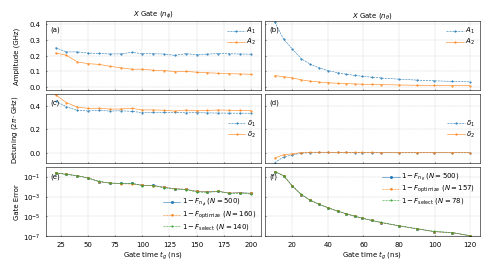

In [30]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(5.6, 2.8), 
                       gridspec_kw={"height_ratios": [2, 2, 2]})
fig.subplots_adjust(hspace=0.05, wspace=0.02)

# Plot f_phi on left column (ax[:, 1])
ax[0, 0].plot(f_phi["tg"], f_phi["drive_amp_1"], ".--", label=r"$A_1$", ms=ms)
ax[0, 0].plot(f_phi["tg"], f_phi["drive_amp_2"], ".-", label=r"$A_2$", ms=ms)
ax[1, 0].plot(f_phi["tg"], f_phi["detune_1"], ".--", label=r"$\delta_1$", ms=ms)
ax[1, 0].plot(f_phi["tg"], f_phi["detune_2"], ".-", label=r"$\delta_2$", ms=ms)
ax[2, 0].plot(f_phi["tg"], 10 ** f_phi["f_500"], "s-", label=r"$1-F_{n_\phi}\ (N=500)$", ms=ms)
ax[2, 0].plot(f_phi["tg"], 10 ** f_phi["f_160"], "v--", label=r"$1-F_{\rm optimize}\ (N=160)$", ms=ms)
ax[2, 0].plot(f_phi["tg"], 10 ** f_phi["f_truc140_ideal"], ".--", label=r"$1-F_{\rm select}\ (N=140)$", ms=ms)
# ax[2, 0].plot(120.005, 10 ** (-2.06302516), "*", ms=5, markerfacecolor=colors[0], markeredgecolor="none")

# Plot f_theta on right column (ax[:, 0])
ax[0, 1].plot(f_theta["tg"], f_theta["drive_amp_1"], ".--", label=r"$A_1$", ms=ms)
ax[0, 1].plot(f_theta["tg"], f_theta["drive_amp_2"], ".-", label=r"$A_2$", ms=ms)
ax[1, 1].plot(f_theta["tg"], f_theta["detune_1"], ".--", label=r"$\delta_1$", ms=ms)
ax[1, 1].plot(f_theta["tg"], f_theta["detune_2"], ".-", label=r"$\delta_2$", ms=ms)
ax[2, 1].plot(f_theta["tg"], 10 ** f_theta["f_500"], "s-", label=r"$1-F_{n_\theta}\ (N=500)$", ms=ms)
ax[2, 1].plot(f_theta["tg"], 10 ** f_theta["f_157"], "v--", label=r"$1-F_{\rm optimize}\ (N=157)$", ms=ms)
ax[2, 1].plot(f_theta["tg"], 10 ** f_theta["f_78"], ".--", label=r"$1-F_{\rm select}\ (N=78)$", ms=ms)
# ax[2, 1].plot(25.020473, 10 ** (-2.79402547), "*", ms=5, markerfacecolor=colors[0], markeredgecolor="none")

labels = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]]
for i in range(3):
    for j in range(2):
        # ax[i, j].text(-0.09, 1.06 if j == 0 else 1.04, order[i], transform=ax[i, j].transAxes, va="top")
        ax[i, j].text(0.02, 0.92, labels[i][j], transform=ax[i, j].transAxes,
                      fontsize=Fontsize_legend, va="top", ha="left")        
        ax[i, j].legend(loc="best", fontsize=Fontsize_legend,
                        frameon=False, handlelength=2.5, handletextpad=0.2,
                        handleheight=0.01, borderpad=0.2, labelspacing=0.1,)
        ax[i, j].grid(linewidth=0.2, linestyle="--")
for j in range(2):
    ax[2, j].set_yscale("log")
    ax[j, 0].set_xticklabels([])
    ax[j, 1].set_xticklabels([])    
    ax[0, j].set_ylim(-0.02, 0.42)
    ax[1, j].set_ylim(-0.09, 0.5)
    ax[2, j].set_ylim(1e-7, 1e0)
    ax[2, j].set_xlabel("Gate time $t_g$ (ns)", labelpad=1)
    ax[0, j].set_title(["$X$ Gate ($n_\\phi$)", "$X$ Gate ($n_\\theta$)"][j], pad=2)
    ax[1, j].legend(loc="center right", fontsize=Fontsize_legend, frameon=False, handlelength=2.5, handletextpad=0.2,
                        handleheight=0.01, borderpad=0.2, labelspacing=0.1,)

ax[2, 0].legend(loc="lower right", fontsize=Fontsize_legend, frameon=False, handlelength=2.5, handletextpad=0.2,
                        handleheight=0.01, borderpad=0.2, labelspacing=0.1,)
for i in range(3):
    ax[i, 0].set_ylabel(["Amplitude (GHz)", "Detuning ($2\pi\cdot$GHz)", "Gate Error"][i])  # Increase value for more left shift
    ax[i, 0].yaxis.set_label_coords(-0.12, 0.5)  # Adjust -0.22 as needed    
    ax[i, 1].tick_params(labelleft=False)
# fig.align_ylabels(ax[:, 0])
plt.savefig("pdf_before_inkscape/params_1q.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

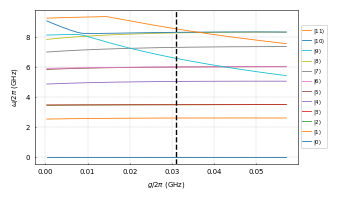

In [3]:
data = np.load('data/eval_vs_g_crossing.npz', allow_pickle=True)
label_idx = [f"$\left|{i}\\right\\rangle$" for i in np.arange(0,15)]

fig, ax = plt.subplots(figsize=(3.4, 2))
for idx in np.arange(0,12):
# for idx in [8,9]:
    plt.plot(np.array(data['g']) / (2*np.pi), np.array(data['E0'])[idx], '-', label=label_idx[idx], linewidth=linewidth * 1.5)
    plt.xlabel('$g/2\pi$ (GHz)')
    plt.ylabel(r'$\omega/2\pi$ (GHz)')
    # plt.title('Two coupled zp: Qubit 1')
    plt.legend()
plt.axvline(0.031, color='black', linestyle='--', linewidth=1)    

handles, labels = ax.get_legend_handles_labels()
legend = ax.legend(handles[::-1], labels[::-1], loc='center left', bbox_to_anchor=(1, 0.5), 
          fontsize=Fontsize_legend * 0.8, frameon=True, handlelength=1.5, 
          handletextpad=0.5, handleheight=0.5, labelspacing=0.2, borderpad=0.2,)
legend.get_frame().set_linewidth(0.5)  # Reduce frame (border) thickness
legend.get_frame().set_alpha(1)  # 0.5 makes the legend 50% transparent
plt.grid(linewidth=0.2, linestyle="--")
plt.savefig("pdf_before_inkscape/eval_vs_g_full.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)


# Intro


In [4]:
def potential_zeropi(theta, phi):
    phiext = 0.0
    return -2 * EJ * np.cos(theta) * np.cos(phi - np.pi * phiext) + EL * phi**2 + 2 * EJ

### Fig. 1d

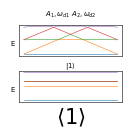

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(1.33, 1))
ax[0].plot(e_flux[:, 0], e_flux[:, 1:])
ax[0].set_title(r"$A_1,\omega_{d1}\ A_2,\omega_{d2}$")

ax[1].plot(e_ng[:, 0], e_ng[:, 1:])
ax[0].set_xlabel(r"$ |1\rangle$", labelpad=3)
ax[1].set_xlabel(r"$ {\left\langle 1\right\rangle}$", labelpad=3, fontsize=15)
plt.subplots_adjust(hspace=0.5)
for ax in fig.get_axes():
    ax.set_xticks([])
    ax.set_yticks([])  # Remove y-ticks
    ax.set_yticklabels([])  # Remove y-tick labels
    ylabel = ax.set_ylabel("E", labelpad=5, rotation=0, loc="center")
    ylabel.set_position((-0.1, 0.3))  # Lower the label manually by changing the second value (y-position)
    ax.tick_params(axis="x", pad=2)  # Adjust padding for x-axis ticks
plt.savefig("pdf_before_inkscape/latex.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

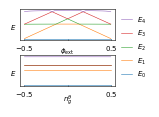

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(1.45, 1))

lines = ax[0].plot(e_flux[:, 0], e_flux[:, 1:])
ax[0].set_xlabel("$\phi_{\\rm ext}$", labelpad=-4)
ax[1].plot(e_ng[:, 0], e_ng[:, 1:])
ax[1].set_xlabel(r"$n_g^\theta$", labelpad=-4)
plt.subplots_adjust(hspace=0.5, right=0.78)  # Leave space on the right
for a in fig.get_axes():
    a.set_xticks([-0.5, 0, 0.5], ["$-0.5$", '', "$0.5$"])
    a.set_yticks([])
    a.set_yticklabels([])
    ylabel = a.set_ylabel("$E$", labelpad=5, rotation=0, loc="center")
    ylabel.set_position((-0.1, 0.3))
    a.tick_params(axis="x", pad=2)

labels = [f"$E_{i}$" for i in range(len(lines))]  # Label each eigenvalue
fig.legend( handles=lines[::-1], labels=labels[::-1], loc="center left",
    bbox_to_anchor=(0.78, 0.5), frameon=False, handlelength=1.5, fontsize=Fontsize_legend, )

plt.savefig("pdf_before_inkscape/1_energy.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

### Fig. 1b

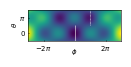

In [7]:
phi_vec = np.linspace(-3 * np.pi, 3 * np.pi, 301)
theta_vec = np.linspace(-0.5 * np.pi, 1.5 * np.pi, 301)
phi, theta = np.meshgrid(phi_vec, theta_vec)

fig, ax = plt.subplots(figsize=(1.2, 0.4))
plt.imshow( potential_zeropi(theta, phi), origin="lower", aspect="auto", 
    extent=[phi_vec[0], phi_vec[-1], theta_vec[0], theta_vec[-1]], )
plt.vlines( x=0, ymin=-0.5 * np.pi, ymax=0.5 * np.pi, color="white", linestyle="-", linewidth=0.4, )
lines = plt.vlines( x=np.pi, ymin=0.5 * np.pi, ymax=1.5 * np.pi, color="white", linestyle="--", linewidth=0.4, )
lines.set_linestyle((0, DASH))
ax.set_xticks([-2 * np.pi, 2 * np.pi], ["$-2\pi$", "$2\pi$"])
ax.set_xlabel(r"$\phi$", labelpad=-4)
ax.set_yticks([0, np.pi], ["0", "$\pi$"])
ax.set_ylabel(r"$\theta$", labelpad=0)
ax.tick_params(axis="both", pad=2)  # Adjust padding for x-axis ticks
plt.savefig("pdf_before_inkscape/1_potential2d.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

### Fig. 1c

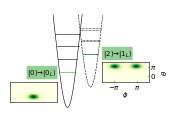

In [8]:
theta_1 = np.linspace(-2, 2, num=50)
theta_2 = np.linspace(1.47, 6.28 - 1.47, num=50)
eval_zp = np.array([        6.40836721,       8.91173084,        9.80996825,        9.83378077,
        11.24434186,        12.19997287,        12.2769947,        13.37183189,
        14.19848836,        14.50087939,    ])

## double valley and levels
fig, ax = plt.subplots(figsize=(0.66, 1.33))
plt.plot( theta_1, potential_zeropi(theta_1, 0), color="black", linestyle="-", )
plt.plot( theta_2, potential_zeropi(theta_2, np.pi), color="black", linestyle="--", )
plt.xlim(-2, 5)
valley = [0, 0, 1, 1, 0, 1, 1, 0, 1, 1]
for i, evals in enumerate(eval_zp):
    if valley[i] == 0:
        x0 = -np.arccos(-0.5 * evals / EJ + 1)
        if i == 0:
            plt.axhline( y=evals, xmin=(x0 + 2) / 7, xmax=(-x0 + 2) / 7, 
                        linestyle="-", color=colors[2], )
        else:
            plt.axhline( y=evals, xmin=(x0 + 2) / 7, xmax=(-x0 + 2) / 7, 
                        linestyle="-", color="black", )

    else:
        x0 = np.arccos(0.5 * (evals - EL * np.pi**2 - 2 * EJ) / EJ)
        if i == 2:
            plt.axhline( y=evals, xmin=(x0 + 2) / 7, xmax=(2 * np.pi - x0 + 2) / 7, 
                        linestyle="-", color=colors[2], )
        else:
            lines = plt.axhline( y=evals, xmin=(x0 + 2) / 7, xmax=(2 * np.pi - x0 + 2) / 7, 
                                linestyle="--", color="black", )
            lines.set_linestyle((0, DASH))


## text
ax.text( -5.5, 6, r"$|0_{}\rangle\to\left|0_L\right\rangle$", color="black",
    bbox=dict( facecolor=colors[2], edgecolor="none", alpha=0.5, boxstyle="round,pad=0.1" ), )
ax.text( 4.8, 9.5, r"$\left|2_{}\right\rangle\to\left|1_L\right\rangle$", color="black",
    bbox=dict( facecolor=colors[2], edgecolor="none", alpha=0.5, boxstyle="round,pad=0.1" ), )
ax.axis("off")

## wavefuction inset
state_0 = np.loadtxt("data/eigenvector_0.txt", delimiter=",")
state_2 = np.loadtxt("data/eigenvector_2.txt", delimiter=",")
## 0 state
ax1 = inset_axes( ax, width=0.47, height=0.2, bbox_transform=ax.transAxes, 
                 bbox_to_anchor=(-0.38, 0.2), loc="center", )
[phi_min, theta_min] = -6 * np.pi, -0.7 * np.pi
[phi_max, theta_max] = 6 * np.pi, 1.5 * np.pi
ax1.imshow( state_0, extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap="YlGn" )
ax1.set_xlim(-2 * np.pi, 2 * np.pi)
ax1.invert_yaxis()
ax1.set_xticks([])  # Remove x-axis ticks
ax1.set_yticks([])  # Remove y-axis ticks

## 2 state
ax1 = inset_axes( ax, width=0.47, height=0.2, bbox_transform=ax.transAxes, bbox_to_anchor=(1.42, 0.39), loc="center", )
ax1.imshow( state_2, extent=[phi_min, phi_max, theta_max, theta_min], aspect="auto", cmap="YlGn" )
ax1.set_xlim(-2 * np.pi, 2 * np.pi)
ax1.set_xticks([-np.pi, np.pi], ["$-\pi$", "$\pi$"])
ax1.set_xlabel("$\phi$", labelpad=-1)
ax1.set_yticks([0, np.pi], ["0", "$\pi$"])
ax1.set_ylabel("$\\theta$", labelpad=2)
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")
ax1.tick_params(axis="both", pad=1)  # Adjust padding for x-axis ticks
ax1.invert_yaxis()
plt.savefig("pdf_before_inkscape/1_double_well.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

# Matrix element in X-gate

In [9]:
truc1 = 300
evals = eval0 - eval0[0]
def get_w_trans(truncation, evals, n_op, state_pop):
    thresh = 1e-4
    hspace = [0, 2]
    for s in hspace:
        for i in range(truncation):
            if np.abs(n_op[s, i] / (2 * np.pi)) > thresh and i not in hspace:
                hspace.append(i)
    hspace.sort()

    n_op = n_op[np.ix_(hspace, hspace)]
    w_trans = []
    trans_int = []
    n_trans = []
    for i, state_i in enumerate(hspace):
        if state_i in state_pop:
            for j, state_j in enumerate(hspace):
                if i < j and np.abs(n_op[i, j] / (2 * np.pi)) > thresh:
                    w_trans.append(np.round(np.abs(evals[state_i] - evals[state_j]), 8))
                    trans_int.append((state_i, state_j))
                    n_trans.append(np.round(np.abs(n_op[i, j] / (2 * np.pi)), 3))
    sort_idx = np.argsort(w_trans)
    w_trans = np.sort(np.round(w_trans, 3))
    n_trans = [np.round(n_trans[i], 3) for i in sort_idx]
    trans_int = [trans_int[i] for i in sort_idx]
    return w_trans, n_trans, trans_int

In [10]:
eval0 = np.array([        0.0,        2.50720437,        3.40252309,        3.42632766,
        4.84540857,        5.79847648,        5.87470899,        6.9825898,
        7.80694319,        8.10000899,  ])
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [
    39.991616,    0.105045,    0.028058,    0.002171,    0.003988,]  # theta
w_0_7 = np.abs(eval0[7] - eval0[0])
w_2_7 = np.abs(eval0[7] - eval0[2])
wd1_theta = w_0_7 + detune_A
wd2_theta = w_2_7 + detune_B
print("wd1_theta=", wd1_theta)
print("wd2_theta=", wd2_theta)
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [
    120.004766,    0.209273,    0.104767,    0.341188,    0.360503,]  # phi
w_0_9 = np.abs(eval0[9] - eval0[0])
w_2_9 = np.abs(eval0[9] - eval0[2])
wd1_phi = w_0_9 + detune_A
wd2_phi = w_2_9 + detune_B
print("wd1_phi=", wd1_phi)
print("wd2_phi=", wd2_phi)

wd1_theta= 6.9847608
wd2_theta= 3.5840547100000006
wd1_phi= 8.44119699
wd2_phi= 5.0579889


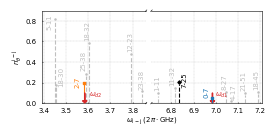

In [11]:
# --- Transition map function ---
def get_transition_style(trans_pair):
    if trans_pair == (0, 7):
        return dict(color=color_07, marker="s", vline="solid", label_offset=(-0.04, 0.01))
    elif trans_pair == (2, 7):
        return dict(color=color_27, marker="s", vline="solid", label_offset=(-0.04, -0.03))
    elif trans_pair == (7, 25):
        return dict(color=color_leakage_main, marker="D", vline="--", label_offset=(0.01, -0.05))
    elif trans_pair == (5, 11):
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(-0.04, -0.1))
    elif trans_pair == (18, 30):
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(0.01, -0.01))
    elif trans_pair == (25, 38):
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(-0.025, 0.035))
    elif trans_pair == (4, 17):
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(0.002, 0.02))
    elif trans_pair == (11, 32):
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(-0.025, 0.03))
    else:
        return dict(color=medium_gray, marker=".", vline="--", label_offset=(-0.02, 0.03))

# --- Arrow drawer ---
def draw_drive_arrow(bax, w_drive, label, dx_label=0.05, color=colors[3], zorder=1):
    bax.annotate("", xy=(w_drive, 0), xytext=(w_drive, 0.1),
                 arrowprops=dict(color=color, shrink=0.02, headwidth=3,
                                 headlength=1.5, width=0.05, alpha=1), zorder=zorder)
    bax.text(w_drive + dx_label, 0.03, label, color=color, ha="center", va="bottom")

# --- Setup values (presumed already defined) ---
state_theta = [0, 1, 2, 4, 5, 7, 8, 11, 25] + [12, 16, 17, 18, 21, 23]  # theta
w_trans, n_trans, trans_int = get_w_trans(truc1, evals, n_theta0, state_theta)

medium_gray = '0.75'
light_gray = '0.9'
color_07 = colors[0]
color_27 = colors[1]
color_leakage_main = "black"
alpha_leakage = 0.3

size_mark = 2.5
size_text = 5
width = 0.8
xlims = ((3.39, 3.86), (6.71, 7.21))

# --- Create plot ---
fig = plt.figure(figsize=(2.85, 1.2))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

# --- Drive arrows ---
draw_drive_arrow(bax, wd1_theta, r"$\omega_{d1}$", dx_label=0.043,zorder=1)
draw_drive_arrow(bax, wd2_theta, r"$\omega_{d2}$", dx_label=0.05, zorder=4)

# --- Transition plotting ---
for i, (w, n) in enumerate(zip(w_trans, n_trans)):
    if n < 0.01:
        continue
    trans_pair = trans_int[i]

    if any(xlim[0] < w < xlim[1] for xlim in xlims):
        style = get_transition_style(trans_pair)
        color = style["color"]
        marker = style["marker"]
        line_style = style["vline"]
        dx, dy = style["label_offset"]

        bax.scatter(w, n, color=color, s=size_mark, marker=marker, zorder=3, alpha=1)
        ymax = n if line_style == "solid" else max(n - 0.02, 0)
        bax.vlines(w, ymin=0, ymax=ymax, color=color, linestyles=line_style, 
        linewidth=width, zorder=2, alpha=1)
        label = f"{trans_pair[0]}-{trans_pair[1]}"
        bax.text(w + dx, n + dy, label, rotation=90, fontsize=size_text, color=color, alpha=1)

# --- Labels & Save ---
bax.set_ylim(0, 0.9)
bax.grid(linewidth=0.2, linestyle="--")
bax.set_xlabel(r"$\omega_{\rm i-j}\ (2\pi\cdot {\rm GHz})$", labelpad=9)
bax.set_ylabel(r"$n_\theta^{\rm i-j}$", labelpad=13)
plt.savefig("pdf_before_inkscape/xgate_ntheta.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)


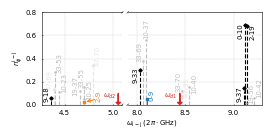

In [12]:
# -----------------------------
# config & constants
# -----------------------------
alpha_other = 1
color_0 = colors[0]
color_2 = colors[1]

medium_gray = '0.75'
light_gray  = '0.9'

size_mark = 2.5
size_text = 5
width = 0.8
linewidth_arrow = width

xlims = ((4.26, 5.1), (7.9, 9.3))  # 7 state
thr = 0.01  # n_trans visibility threshold

# classify sets
trans_lambda  = {(0, 9), (2, 9)}
trans_level_1 = {(0, 10), (2, 19), (9, 33), (9, 37), (9, 18)}
trans_level_3 = {(47, 69), (47, 70), (47, 91)}

# per-class default styles
CLASS_STYLE = {
    "lambda":  dict(color=None,        marker="s", vline="solid", alpha=1.0),
    "level1":  dict(color="black",     marker="D", vline="--",    alpha=1.0),
    "level2":  dict(color=medium_gray, marker=".", vline="--",    alpha=alpha_other),
    "level3":  dict(color=light_gray,  marker="^", vline="--",    alpha=alpha_other),
}

# per-class default label offsets (dx, dy)
DEFAULT_OFFSET = {
    "lambda": (0.02, 0.01),
    "level1": (-0.08, -0.11),
    "level2": (-0.03, 0.018),
    "level3": (0.02, 0.005),
}

# pair-specific overrides (dx, dy)
OFFSET_OVERRIDE = {
    # lambda
    (0,  9): (0.015, -0.01),
    (2,  9): (0.12,   0.01),

    # level-1
    (0, 10): (-0.08, -0.11),
    (9, 33): (-0.08, -0.11),
    (9, 37): (-0.08, -0.11),
    # (19,37): (-0.08, -0.11),
    # (10,37): ( 0.02, -0.11),
    (2, 19): ( 0.02, -0.11),
    (9, 18): (-0.08, -0.03),

    # level-3
    (47,69): (-0.08,  0.005),
    (47,70): ( 0.02,  0.005),
    (47,91): ( 0.02,  0.005),

    # level-2 examples
    (10,25): ( 0.02,  0.005),
    (10,42): ( 0.02,  0.005),
    (19,56): ( 0.02,  0.005),
    (33,53): ( 0.02,  0.005),
    (10,23): ( 0.02,  0.005),
    (33,70): (-0.06,  0.005),
    (33,55): (-0.06,  0.005),
    (10,40): ( 0.02, -0.05),
    # (47,70): ( 0.01,  0.01),
    # (9, 18): (-0.08, -0.04),
    (19,37): (-0.08, -0.04),
    # (9, 33): (-0.08, -0.04),
    (33,69): (-0.07,  0.005),
}

def classify_pair(pair):
    if pair in trans_lambda:
        return "lambda"
    if pair in trans_level_1:
        return "level1"
    if pair in trans_level_3:
        return "level3"
    return "level2"

def pair_style(pair):
    cls = classify_pair(pair)
    style = CLASS_STYLE[cls].copy()

    # lambda class needs different colors for the two specific pairs
    if cls == "lambda":
        style["color"] = color_0 if pair == (0, 9) else color_2
    return cls, style

def label_offset(pair, cls):
    return OFFSET_OVERRIDE.get(pair, DEFAULT_OFFSET[cls])

def in_any_xlim(x, xlims):
    return any(lo < x < hi for lo, hi in xlims)

# -----------------------------
# data
# -----------------------------
state_phi = [0, 2, 9, 10, 19, 33, 47]
w_trans, n_trans, trans_int = get_w_trans(truc1, evals, n_phi0, state_phi)

# -----------------------------
# plot
# -----------------------------
fig = plt.figure(figsize=(2.85, 1.2))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)

for w, n, pair in zip(w_trans, n_trans, trans_int):
    if n <= thr or not in_any_xlim(w, xlims):
        continue

    cls, style = pair_style(pair)
    dx, dy = label_offset(pair, cls)
    color     = style["color"]
    marker    = style["marker"]
    line_style = style["vline"]
    alpha     = style["alpha"]

    bax.scatter(w, n, color=color, s=size_mark, marker=marker, zorder=2, alpha=alpha)
    ymax = n if line_style == "solid" else max(n - 0.02, 0)
    bax.vlines(w, ymin=0, ymax=ymax, color=color, linestyles=line_style,
               linewidth=width, zorder=1, alpha=alpha)
    bax.text(w + dx, n + dy, f"{pair[0]}-{pair[1]}", rotation=90,
             fontsize=size_text, color=color, alpha=alpha)

# special annotate for (2, 9)
if (2, 9) in trans_int:
    i = trans_int.index((2, 9))
    bax.annotate(
        None, xy=(w_trans[i], n_trans[i]), xytext=(4.84, 0.05),
        arrowprops=dict(facecolor=color_2, edgecolor=color_2, arrowstyle="->",
                        alpha=1, linewidth=linewidth_arrow)
    )

# drive arrows
draw_drive_arrow(bax, wd1_phi, r"$\omega_{d1}$", dx_label=-0.09)
draw_drive_arrow(bax, wd2_phi, r"$\omega_{d2}$", dx_label=-0.09)

# axes / save
bax.set_ylim(0, 0.8)
bax.grid(linewidth=0.2, linestyle="--")
bax.set_xlabel(r"$\omega_{\rm i-j}\ (2\pi\cdot {\rm GHz})$", labelpad=10)
bax.set_ylabel(r"$n_\phi^{\rm i-j}$", labelpad=12)
plt.savefig("pdf_before_inkscape/xgate_nphi.pdf",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.02)


# Matrix element in two-qubit gate

In [13]:
w_ij = [
    5.521,    6.442,    6.487,    14.676,    14.697,
    15.093,    15.139,    15.922,    15.984,    16.273,
    16.309,    21.267,    21.28,    23.33,    23.606,
    23.77,    23.819,    24.111,    24.977,    25.528,
    42.848,    42.861,    45.4,    45.564,    45.905,
    46.771,    47.322,
]
N_theta1 = [
    0.01006296683299849,    0.0009430557718534819,    0.0009106078683545906,    0.3863029332392685,
    0.31204454924097497,    0.5763099854450343,    0.43392707448083284,    1.277528320032748,
    1.2038413996613069,    1.3161895172523022,    1.281211778695078,    0.0062621325530010635,
    0.007058279502190822,    0.0007772117736662768,    0.04229947657686712,    0.05858154014129684,
    0.00035018201092833006,    0.04713334744094287,    0.029259334352486052,    0.017430978675981625,
    0.00037225416041852084,    6.95574620811779e-05,    0.02631807415407655,    0.03737095859672815,
    0.03175194764741163,    0.022577207158589997,    0.014575116316498797,
]
N_theta2 = [
    0.0005073155023982456,    0.01806535873522096,    0.017307777063534924,    1.2388890320185455,
    1.2575414456546836,    1.1961358362690118,    1.2521911350100485,    0.344379180247553,
    0.5405140185264158,    0.2684172492747845,    0.3936120006396247,    0.11616354632418865,
    0.11659057848338912,    0.014881754997691296,    0.001350302451183277,    0.0015864655322617373,
    0.01047459928617664,    0.001359221814392976,    0.0008865834076196863,    0.0004335124583360326,
    0.044966597964229076,    0.045243636994150134,    0.006454377125753926,    9.33510101116047e-05,
    0.0057492325068492015,    0.00040075985462874195,    0.0024334990366659567,
]
trans = [
    "2,2-1,2",    "0,2-0,1",    "2,2-2,1",    "2,2-2,5",
    "0,2-0,5",    "2,0-2,1",    "0,0-0,1",    "2,2-5,2",
    "2,0-5,0",    "0,2-1,2",    "0,0-1,0",    "2,2-2,8",
    "0,2-0,8",    "2,2-9,1",    "2,0-1,4",    "2,2-8,2",
    "0,2-1,4",    "2,0-8,0",    "2,2-4,5",    "2,0-4,1",
    "2,0-2,8",    "0,0-0,8",    "0,0-1,4",    "0,2-8,2",
    "0,0-8,0",    "0,2-4,5",    "0,0-4,1",
]

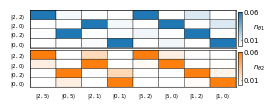

In [14]:
# state_interest = [ '50', '01', '10',  '05', '12', '21',  '25', '52']
state_interest = [ '25', '05', '21', '01', '52', '50', '12', '10']
state_idx = [trunc_states.index(i) for i in state_interest]
x_tick_label = ["$|" + trunc_states[i][0]+ ','+ trunc_states[i][1] + "\\rangle$" for i in range(len(trunc_states))]
custom_cmap1 = LinearSegmentedColormap.from_list("blue_white", ["#ffffff", colors[0]])


n_theta1_truc = qt.Qobj(    np.loadtxt("data/n_theta1_dress.txt", delimiter=",").view(complex))
n_theta2_truc = qt.Qobj(    np.loadtxt("data/n_theta2_dress.txt", delimiter=",").view(complex))
vmax = 0.06
fig, ax = plt.subplots(figsize=(2.65, 1.0), nrows=2)
plt.subplots_adjust(hspace=0.06)
mat = n_theta1_truc.full()[:4, state_idx]
cbar0 = ax[0].pcolor(np.abs(mat), edgecolors="k", cmap=custom_cmap1, vmax=vmax)
mat2 = n_theta2_truc.full()[:4, state_idx]
cbar1 = ax[1].pcolor(np.abs(mat2), edgecolors="k", cmap=custom_cmap2, vmax=vmax)

size_text = 4
for i in range(2):
    ax[i].set_xticks(np.arange(0.5, mat.shape[1], 1))
    ax[i].set_yticks(np.arange(0.5, mat.shape[0], 1))
    ax[i].set_yticklabels(x_tick_label[: mat.shape[0]])  # Set fontsize for yticks
ax[0].set_xticklabels(labels="")  # Set fontsize for xticks
ax[1].set_xticklabels(np.array(x_tick_label)[state_idx].tolist())  # Set fontsize for xticks
ax[0].tick_params( axis="both", length=0, labelsize=size_text)  # Adjust padding for x-axis ticks
ax[1].tick_params(    axis="both", length=0, labelsize=size_text)  # Adjust padding for x-axis ticks

colorbar0 = inset_axes(ax[0], width="2%", height="90%", loc="right", borderpad=-0.9)
cb0 = fig.colorbar(cbar0, cax=colorbar0, ticks=[0.01, 0.06])
cb0.ax.set_yticklabels(["0.01", "0.06"])
cb0.set_label(r"$n_{\theta 1}$", rotation=0, labelpad=0)
cb0.ax.yaxis.label.set_position((1., 0.65))  # y=0.5 is center; >0.5 moves up, <0.5 moves down
cb0.ax.tick_params(pad=1)

colorbar1 = inset_axes(ax[1], width="2%", height="90%", loc="right", borderpad=-0.9)
cb1 = fig.colorbar(cbar1, cax=colorbar1, ticks=[0.01, 0.06])
cb1.ax.set_yticklabels(["0.01", "0.06"])
cb1.set_label(r"$n_{\theta 2}$", rotation=0, labelpad=0)
cb1.ax.yaxis.label.set_position((1., 0.65))  # y=0.5 is center; >0.5 moves up, <0.5 moves down
cb1.ax.tick_params(pad=1)

plt.savefig("pdf_before_inkscape/cz_ntheta_table.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

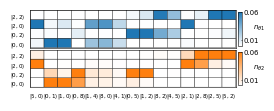

In [15]:
x_tick_label = ["$|" + trunc_states[i][0]+ ','+ trunc_states[i][1] + "\\rangle$" for i in range(len(trunc_states))]
custom_cmap1 = LinearSegmentedColormap.from_list("blue_white", ["#ffffff", colors[0]])

# np.savetxt('data/n_theta1.txt', np.array(n_theta1_truc).view(float), delimiter=',')
# np.savetxt('data/n_theta2.txt', np.array(n_theta2_truc).view(float), delimiter=',')
n_theta1_truc = qt.Qobj(    np.loadtxt("data/n_theta1_dress.txt", delimiter=",").view(complex))
n_theta2_truc = qt.Qobj(    np.loadtxt("data/n_theta2_dress.txt", delimiter=",").view(complex))
vmax = 0.06
fig, ax = plt.subplots(figsize=(2.65, 1.0), nrows=2)
plt.subplots_adjust(hspace=0.06)
mat = n_theta1_truc.full()[:4, 4:-1]
cbar0 = ax[0].pcolor(np.abs(mat), edgecolors="k", cmap=custom_cmap1, vmax=vmax)
mat2 = n_theta2_truc.full()[:4, 4:-1]
cbar1 = ax[1].pcolor(np.abs(mat2), edgecolors="k", cmap=custom_cmap2, vmax=vmax)

size_text = 4
for i in range(2):
    ax[i].set_xticks(np.arange(0.5, mat.shape[1], 1))
    ax[i].set_yticks(np.arange(0.5, mat.shape[0], 1))
    ax[i].set_yticklabels(x_tick_label[: mat.shape[0]])  # Set fontsize for yticks
ax[0].set_xticklabels(labels="")  # Set fontsize for xticks
ax[1].set_xticklabels(x_tick_label[4:-1])  # Set fontsize for xticks
ax[0].tick_params( axis="both", length=0, labelsize=size_text)  # Adjust padding for x-axis ticks
ax[1].tick_params(    axis="both", length=0, labelsize=size_text)  # Adjust padding for x-axis ticks

colorbar0 = inset_axes(ax[0], width="2%", height="90%", loc="right", borderpad=-0.9)
cb0 = fig.colorbar(cbar0, cax=colorbar0, ticks=[0.01, 0.06])
cb0.ax.set_yticklabels(["0.01", "0.06"])
cb0.set_label(r"$n_{\theta 1}$", rotation=0, labelpad=0)
cb0.ax.yaxis.label.set_position((1., 0.65))  # y=0.5 is center; >0.5 moves up, <0.5 moves down
cb0.ax.tick_params(pad=1)

colorbar1 = inset_axes(ax[1], width="2%", height="90%", loc="right", borderpad=-0.9)
cb1 = fig.colorbar(cbar1, cax=colorbar1, ticks=[0.01, 0.06])
cb1.ax.set_yticklabels(["0.01", "0.06"])
cb1.set_label(r"$n_{\theta 2}$", rotation=0, labelpad=0)
cb1.ax.yaxis.label.set_position((1., 0.65))  # y=0.5 is center; >0.5 moves up, <0.5 moves down
cb1.ax.tick_params(pad=1)

plt.savefig("pdf_before_inkscape/cnot_ntheta_table.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

In [16]:
idx = trans.index("0,2-8,2")
print(idx, w_ij[idx]/(2*np.pi), N_theta1[idx], N_theta2[idx])
idx = trans.index("2,2-8,2")
print(idx, w_ij[idx]/(2*np.pi), N_theta1[idx], N_theta2[idx])
idx = trans.index("2,0-5,0")
print(idx, w_ij[idx]/(2*np.pi), N_theta1[idx], N_theta2[idx])

23 7.251735827039119 0.03737095859672815 9.33510101116047e-05
15 3.783112997294352 0.05858154014129684 0.0015864655322617373
8 2.543932610380855 1.2038413996613069 0.5405140185264158


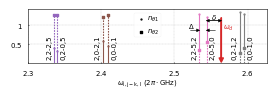

In [17]:
size_mark = 1.5
width = 0.8
size_text = 5
fig, ax = plt.subplots(figsize=(3.08, 0.7))
for i in np.arange(3, 11):
    color = colors[4 + int((i - 3) / 2)]
    if N_theta1[i] > N_theta2[i]:
        lines = plt.vlines( w_ij[i], ymin=0, ymax=N_theta2[i], color=color, 
                           linestyles="dashed", linewidth=width, zorder=1, )
        lines.set_linestyle((0, DASH))
        plt.vlines( w_ij[i], ymin=N_theta2[i], ymax=N_theta1[i], color=color, 
                   linestyles="solid", linewidth=width, zorder=1, )
    else:
        plt.vlines( w_ij[i], ymin=0, ymax=N_theta1[i], color=color, 
                   linestyles="solid", linewidth=width, zorder=1, )
        lines = plt.vlines( w_ij[i], ymin=N_theta1[i], ymax=N_theta2[i], 
                           color=color, linestyles="dashed", linewidth=width, zorder=1, )
        lines.set_linestyle((0, DASH))
    plt.scatter( w_ij[i], N_theta1[i], color=color, s=size_mark, marker=".", zorder=2 )  # Marker for solid line
    plt.scatter( w_ij[i], N_theta2[i], color=color, s=size_mark, marker="s", zorder=2 )  # Marker for solid line

i = 0
plt.scatter( w_ij[i], N_theta1[i], color="black", s=size_mark, marker=".", 
            zorder=2, label="$n_{\\theta 1}$", )  # Marker for solid line
plt.scatter( w_ij[i], N_theta2[i], color="black", s=size_mark, marker="s", 
            zorder=2, label="$n_{\\theta 2}$", )  # Marker for solid line

i = 3
y_value = 0.1
x_left = -0.045
x_right = 0.055
plt.text( w_ij[i] + x_left, y_value, "2,2-2,5", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )
plt.text( w_ij[i + 1] + x_right, y_value, "0,2-0,5", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )

plt.text( w_ij[i + 2] + x_left, y_value, "2,0-2,1", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )
plt.text( w_ij[i + 3] + x_right, y_value, "0,0-0,1", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )

plt.text( w_ij[i + 4] + x_left, y_value, "2,2-5,2", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )
plt.text( w_ij[i + 5] + x_right, y_value, "2,0-5,0", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )

plt.text( w_ij[i + 6] + x_left, y_value, "0,2-1,2", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )
plt.text( w_ij[i + 7] + x_right, y_value, "0,0-1,0", ha="center", fontsize=size_text, 
         va="bottom", rotation=90, )
ax.set_xticks(
    2 * np.pi * np.arange(2.3, 2.626, 0.1), ["$2.3$", "$2.4$", "$2.5$", "$2.6$"]
)
# ax.set_xticks(np.linspace(14.5, 16.5, num=5), ['$14.5$', '$15.0$', '', '$16.0$', '$16.5$'])
ax.set_yticks([0.5, 1], ["$0.5$", "$1$"])
plt.xlabel(r"$\omega_{\rm i,j-k,l}\ (2\pi\cdot {\rm GHz})$", labelpad=0)
# plt.ylabel('Matrix element $n_{\\theta}$ ', fontsize=SMALL_SIZE, labelpad=4)
legend = plt.legend( loc="upper center", frameon=True, handlelength=1.5, handletextpad=0.2, 
                    handleheight=0.01, borderpad=0.2, )
legend.get_frame().set_linewidth(0.1)
plt.xlim(14.45, 16.5)
plt.ylim(0, 1.4)
ax.tick_params(axis="both", pad=4)  # Adjust padding for x-axis ticks

######################################################
### drive freq
w_20_50 = 15.984
detuning = 0.020071
wd = w_20_50 + 2 * np.pi * detuning
plt.annotate( "", xy=(wd, 0.0), xytext=(wd, 1.2),
             arrowprops=dict( color=colors[3], shrink=0.02, headwidth=3, 
                             headlength=3, width=0.2, ), )
plt.text( wd + 0.065, 0.8, r"$\omega_d$", ha="center", va="bottom", color=colors[3], )

######################################################
### detuning
plt.annotate( "", xy=(wd + 0.03, 1.1), xytext=(w_ij[i + 5] - 0.02, 1.1), 
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.4), )
plt.annotate( "", xy=(w_ij[i + 5] - 0.03, 1.1), xytext=(wd + 0.01, 1.1),  
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.4), )
plt.text( 16.05, 1.1, r"$\delta$", ha="center", va="bottom", )

######################################################
### frequency mismatch
plt.annotate( "", xy=(w_ij[i + 4] + 0.03, 0.85), xytext=(w_ij[i + 4] - 0.1, 0.85), 
                arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.4), )
plt.annotate( "", xy=(w_ij[i + 5] - 0.03, 0.85), xytext=(w_ij[i + 5] + 0.1, 0.85), 
                arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.4), )
plt.text( 15.85, 0.85, r"$\Delta$", ha="center", va="bottom", )
plt.grid( linewidth=0.2, linestyle="--", )

plt.savefig("pdf_before_inkscape/cz_ntheta.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

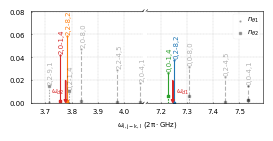

In [18]:
w_ij_0 = np.array(w_ij)/ (2*np.pi)
color_wd = colors[3]
alpha_leakage = 0.3

x_tick_label = ["$" + trans[i] + "$" for i in range(len(trans))]

DASH = (1.5, 1)
width = 0.8
# xlims = ((22.9, 25.6), (44.9, 47.7))
xlims = ((3.6446482, 4.07436654), (7.14605694, 7.59169079))
fig = plt.figure(figsize=(3, 1.2))
bax = brokenaxes(xlims=xlims, wspace=0.03, d=0.004, despine=False, hspace=0.05)

trans_good = ["0,2-8,2", "2,2-8,2", "0,0-1,4","2,0-1,4" ]

for i in range(len(w_ij_0)):
    if trans[i] not in trans_good:
        if N_theta1[i] > N_theta2[i]:
            lines = bax.vlines( w_ij_0[i], ymin=0, ymax=N_theta2[i], color="black",
                linestyles="dashed", linewidth=width, zorder=1, alpha=alpha_leakage, )
            [ line.set_linestyle((0, DASH)) for line in lines ]  # Customize each line's dash pattern
            bax.vlines( w_ij_0[i], ymin=N_theta2[i], ymax=N_theta1[i]-0.002, color="black",
                linestyles="dashed", linewidth=width, zorder=1, alpha=alpha_leakage, )
        else:
            bax.vlines( w_ij_0[i], ymin=0, ymax=N_theta1[i], color="black",
                linestyles="dashed", linewidth=width, zorder=1, alpha=alpha_leakage, )
            lines = bax.vlines( w_ij_0[i], ymin=N_theta1[i], ymax=N_theta2[i]-0.002, color="black", 
                                linestyles="dashed", linewidth=width, zorder=1, alpha=alpha_leakage, )
            [ line.set_linestyle((0, DASH)) for line in lines ]  # Customize each line's dash pattern
        bax.scatter( w_ij_0[i], N_theta1[i], color="black", s=size_mark, marker=".", 
                    alpha=alpha_leakage, zorder=2 )  # Marker for solid line
        bax.scatter( w_ij_0[i], N_theta2[i], color="black", s=size_mark, marker="s", 
        alpha=alpha_leakage, zorder=2 )  # Marker for solid line

i = -1
bax.scatter( w_ij_0[i], N_theta1[i], color="black", s=size_mark, marker=".", 
            zorder=2, label="$n_{\\theta 1}$", alpha=alpha_leakage, )  # Marker for solid line
bax.scatter( w_ij_0[i], N_theta2[i], color="black", s=size_mark, marker="s", 
            zorder=2, label="$n_{\\theta 2}$", alpha=alpha_leakage, )  # Marker for solid line

size_text = 5
x_shift = 0.035 / (2*np.pi)
y_shift = 0.0015
for i in range(len(w_ij_0)):
    for xlim in xlims:
        if xlim[0] < w_ij_0[i] < xlim[1]:
            if trans[i] not in trans_good:
                bax.text( w_ij_0[i] + x_shift + 0.005 / (2*np.pi),
                    np.max([N_theta1[i], N_theta2[i]]) + y_shift,
                    trans[i], ha="center", va="bottom", rotation=90, 
                    fontsize=size_text, alpha=alpha_leakage, )

for i, transition in enumerate(trans_good):
    idx = trans.index(transition)
    lines = bax.vlines( w_ij_0[idx], ymin=0, ymax=N_theta2[idx], color=colors[0 + i], 
                       linestyles="dashed", linewidth=width, zorder=1, )
    [ line.set_linestyle((0, DASH)) for line in lines ]  # Customize each line's dash pattern
    bax.vlines( w_ij_0[idx], ymin=N_theta2[idx], ymax=N_theta1[idx], color=colors[0 + i], 
               linestyles="solid", linewidth=width, zorder=1, )
    bax.scatter( w_ij_0[idx], N_theta1[idx], color=colors[0 + i], s=size_mark, 
                marker=".", zorder=2 )  # Marker for solid line
    bax.scatter( w_ij_0[idx], N_theta2[idx], color=colors[0 + i], s=size_mark, 
                marker="s", zorder=2 )  # Marker for solid line
    bax.text( w_ij_0[idx] + x_shift + 0.005 / (2*np.pi), np.max([N_theta1[idx], N_theta2[idx]]) + y_shift,
        trans[idx], ha="center", va="bottom", rotation=90, fontsize=size_text, color=colors[0 + i],)

bax.set_xlabel(r"$\omega_{\rm i,j-k,l}\ ({\rm 2\pi\cdot GHz})$", labelpad=12)

# bax.set_ylabel('Matrix element $n_{\\theta}$ ', labelpad=20)
bax.tick_params(axis="both", pad=4)  # Adjust padding for x-axis ticks
legend = bax.legend( loc="best", frameon=True, handlelength=1.5,
                    handletextpad=0.2, handleheight=0.01, borderpad=0.2, )
legend.get_frame().set_linewidth(0.1)
bax.set_ylim(0, 0.081)

### wd1
w_02_82 = 45.546 / (2*np.pi)
w_22_82 = 23.753 / (2*np.pi)
detune_1 = -0.003423 / (2*np.pi)
detune_2 = -0.003252 / (2*np.pi)
wd1 = w_02_82 + 2 * np.pi * detune_1
wd2 = w_22_82 + 2 * np.pi * detune_2
bax.annotate( "", xy=(wd1, 0.0), xytext=(wd1, 0.02), 
             arrowprops=dict( color=color_wd, shrink=0.02, headwidth=2, headlength=2, width=0.05 ), )
bax.text( wd1 + 0.25 / (2*np.pi), 0.006, r"$\omega_{d1}$", color=color_wd, ha="center", va="bottom", )

### wd2
bax.annotate( "", xy=(wd2, 0.0), xytext=(wd2, 0.02),  
    arrowprops=dict( color=color_wd, shrink=0.02, headwidth=2, headlength=2, width=0.05 ), )
bax.text( wd2 - 0.2 / (2*np.pi), 0.006, r"$\omega_{d2}$", color=color_wd, ha="center", va="bottom", )
bax.grid(linewidth=0.2, linestyle="--")
plt.savefig("pdf_before_inkscape/cnot_ntheta.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

# Population

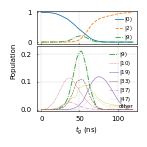

In [19]:
pop_phi = pd.read_csv("data/population_phi.txt").to_numpy()
state_phi = [0, 2, 9, 10, 19, 33, 37, 47]  # phi
col_phi = ["tg"] + [f"$\left|{i}\\right\\rangle$" for i in state_phi] + ["other"]

pop_other_all = pop_phi[:, 4:].sum(axis=1)
fig, ax = plt.subplots( nrows=2, ncols=1, figsize=(1.3, 1.3), gridspec_kw={"height_ratios": [1, 2]} )
plt.subplots_adjust(hspace=0.04)
for i in np.arange(1, 4):
    ax[0].plot( pop_phi[:, 0], gaussian_filter(pop_phi[:, i], 3), ls=linestyle[i - 1], label=col_phi[i], linewidth=linewidth * 1.5, )
ax[1].plot( pop_phi[:, 0], gaussian_filter(pop_phi[:, i], 3), ls=linestyle[i - 1], label=col_phi[i], linewidth=linewidth * 1.5, color=colors[i - 1], )
for i in np.arange(4, 8):
    ax[1].plot( pop_phi[:, 0], gaussian_filter(pop_phi[:, i], 3), ls=linestyle[i - 1], label=col_phi[i], linewidth=linewidth * 1, color=colors[i - 1], )
for i in np.arange(8, 10):
    ax[1].plot( pop_phi[:, 0], gaussian_filter(pop_phi[:, i], 3), ls=linestyle[i - 1], label=col_phi[i], linewidth=linewidth * 0.5, color=colors[i - 1], )
fig.text(-0.08 , 0.5, r"Population", va="center", rotation="vertical") # x=-0.12
ax[0].set_ylim(-0.05, 1.05)
ax[1].set_ylim(-0.005, 0.23)
ax[1].set_yticks([0, 0.1, 0.2])
ax[0].set_xticklabels([])
ax[1].set_xlabel(r"$t_g$ (ns)", labelpad=2) # labelpad=2
for i in range(2):
    ax[i].grid(linewidth=0.2, linestyle="--")
    legend = ax[i].legend( loc="upper right", fontsize=Fontsize_legend * 0.8, frameon=False, handlelength=1.5, 
                            handletextpad=0.2, handleheight=0.01, labelspacing=0.01, borderpad=0.2, )
    legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.savefig("pdf_before_inkscape/xgate_population_phi.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

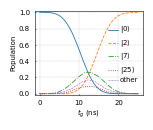

In [20]:
pop_exp = pd.read_csv("data/population_theta_25.txt").to_numpy()
state_theta = [0, 2, 7, 25]  # theta
col_theta = ["tg"] + [f"$|{i}\\rangle$" for i in state_theta] + ["other"]
fig, ax = plt.subplots(figsize=(1.4, 1.1))
plt.subplots_adjust(wspace=0.4)
end = pop_exp.shape[1]
for i in np.arange(1, end - 1):
    ax.plot( pop_exp[:, 0], gaussian_filter(pop_exp[:, i], 6), ls=linestyle[i - 1], label=col_theta[i], linewidth=linewidth * 1.5, )
ax.plot( pop_exp[:, 0], gaussian_filter(pop_exp[:, end - 1], 6), ls=linestyle[end - 1], label=col_theta[end - 1], linewidth=linewidth * 1, )
ax.set_ylim(-0.02, 1.02)
ax.grid(linewidth=0.2, linestyle="--")
ax.set_ylabel(r"Population", labelpad=2)
ax.set_xlabel(r"$t_g$ (ns)", labelpad=1)
legend = ax.legend( loc="center right", fontsize=Fontsize_legend, frameon=False, handlelength=1.5, 
                    handletextpad=0.2, handleheight=0.01, labelspacing=0.2, borderpad=0.2, )
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.savefig("pdf_before_inkscape/xgate_population_theta_25.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

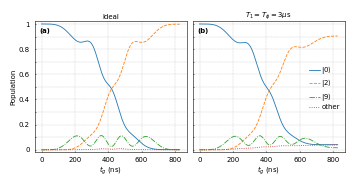

In [21]:
# Read data
pop_exp = pd.read_csv("data/population_phi=True_theta=True_tg=829_ideal.txt").to_numpy()
pop_exp_3us = pd.read_csv("data/population_phi=True_theta=True_tg=829_3us.txt").to_numpy()
# Setup
state_phi_theta = [0, 2, 9]  # theta states
col_theta = ["tg"] + [f"$|{i}\\rangle$" for i in state_phi_theta] + ["other"]
fig, ax = plt.subplots(1, 2, figsize=(4, 1.7))
plt.subplots_adjust(wspace=0.04)
end = pop_exp.shape[1]

# Loop over the two subplots
for i in range(1,end):
    ax[0].plot(pop_exp[:, 0], gaussian_filter(pop_exp[:, i], 6), ls=linestyle[i - 1], label=col_theta[i], linewidth=linewidth * 1.5, )
    ax[1].plot(pop_exp_3us[:, 0], gaussian_filter(pop_exp_3us[:, i], 6), ls=linestyle[i - 1], label=col_theta[i], linewidth=linewidth * 1.5, )
for i in range(2):
    ax[i].text(  0.03, 0.95, order[i], transform=ax[i].transAxes, weight='bold',  va="top"   )    
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].grid(linewidth=0.2, linestyle="--")
    ax[i].set_xlabel(r"$t_g$ (ns)", labelpad=1)
    ax[i].set_xticks(np.arange(0, 810, 200))
ax[0].set_yticks(np.arange(0, 1.1, 0.1), ["0", "", "0.2", "", "0.4", "", "0.6", "", "0.8", "", "1"])
ax[1].set_yticks(np.arange(0, 1.1, 0.1), ["", "", "", "", "", "", "", "", "", "", ""])
ax[0].set_ylabel(r"Population", labelpad=2)
ax[0].set_title(r"Ideal", pad=2)
ax[1].set_title(r"$T_1=T_{\phi}=3\mu$s", pad=2)

# Add legend only to the second subplot
legend = ax[1].legend( loc="center right", fontsize=Fontsize_legend, frameon=False, handlelength=1.5,
                        handletextpad=0.2, handleheight=0.01, labelspacing=0.2, borderpad=0.2, )
legend.get_frame().set_alpha(0.2)
# Save figure
plt.savefig("pdf_before_inkscape/xgate_population_phi+theta_2panels.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)


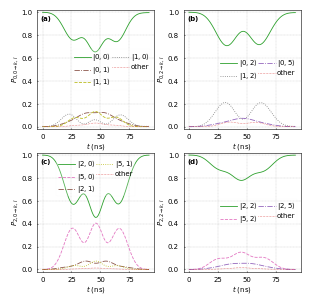

In [22]:
df_00 = pd.read_csv("data/cz_population_tg=91_00_3ncut.txt").to_numpy()
df_02 = pd.read_csv("data/cz_population_tg=91_02_3ncut.txt").to_numpy()
df_20 = pd.read_csv("data/cz_population_tg=91_20_3ncut.txt").to_numpy()
df_22 = pd.read_csv("data/cz_population_tg=91_22_3ncut.txt").to_numpy()
tlist = df_00[:, 0]
col_00 = (    ["tg"]    + [r"$|0,0\rangle$", r"$|0,1\rangle$", 
                           r"$|1,1\rangle$", r"$|1,0\rangle$"]    + ["other"])
col_02 = ["tg"] + [r"$|0,2\rangle$", r"$|1,2\rangle$", r"$|0,5\rangle$"] + ["other"]
col_20 = (    ["tg"]    + [r"$|2,0\rangle$", r"$|5,0\rangle$", 
                           r"$|2,1\rangle$", r"$|5,1\rangle$"]    + ["other"])
col_22 = ["tg"] + [r"$|2,2\rangle$", r"$|5,2\rangle$", r"$|2,5\rangle$"] + ["other"]

sigma = 3
fig, ax = plt.subplots(figsize=(3.4, 3.4), nrows=2, ncols=2)
plt.subplots_adjust(wspace=0.25, hspace=0.2)

color_00 = [colors[2], colors[5], colors[8], colors[7], colors[3]]
color_01 = [colors[2], colors[7], colors[4], colors[3]]
color_10 = [colors[2], colors[6], colors[5], colors[8], colors[3]]
color_11 = [colors[2], colors[6], colors[4], colors[3]]

ls_00 = ["-", "-.", "--", ":", ":"]
ls_01 = ["-", ":", "-.", ":"]
ls_10 = ["-", "--", "-.", ":", ":"]
ls_11 = ["-", "--", "-.", ":"]

for i in np.arange(1, df_00.shape[1] - 1):
    ax[0][0].plot( tlist, gaussian_filter(df_00[:, i], sigma), ls=ls_00[i - 1], 
    lw=linewidth * 1.5, label=col_00[i], color=color_00[i - 1], )
    ax[1][0].plot( tlist, gaussian_filter(df_20[:, i], sigma), ls=ls_10[i - 1], 
                  lw=linewidth * 1.5, label=col_20[i], color=color_10[i - 1], )
i = i + 1
ax[0][0].plot( tlist, gaussian_filter(df_00[:, i], sigma), ls=ls_00[i - 1], 
              label=col_00[i], color=color_00[i - 1], )
ax[1][0].plot( tlist, gaussian_filter(df_20[:, i], sigma), ls=ls_10[i - 1],
                label=col_20[i], color=color_10[i - 1], )

for i in np.arange(1, df_02.shape[1] - 1):
    ax[0][1].plot( tlist, gaussian_filter(df_02[:, i], sigma),
        ls=ls_01[i - 1], lw=linewidth * 1.5, label=col_02[i], color=color_01[i - 1], )
    ax[1][1].plot( tlist, gaussian_filter(df_22[:, i], sigma), ls=ls_11[i - 1],
        lw=linewidth * 1.5, label=col_22[i], color=color_11[i - 1], )
i = i + 1
ax[0][1].plot( tlist, gaussian_filter(df_02[:, i], sigma), ls=ls_01[i - 1],
    lw=linewidth, label=col_02[i], color=color_01[i - 1], )
ax[1][1].plot( tlist, gaussian_filter(df_22[:, i], sigma), ls=ls_11[i - 1],
    lw=linewidth, label=col_22[i], color=color_11[i - 1], )
ylabel_vec = [  r"$P_{0,0 \rightarrow k,l}$", r"$P_{0,2 \rightarrow k,l}$",
                r"$P_{2,0 \rightarrow k,l}$", r"$P_{2,2 \rightarrow k,l}$"]

for i in range(2):
    for j in range(2):
        ax[i][j].set_xlabel(r"$t$ (ns)", labelpad=1)  # Remove y-tick labels
        ax[i][j].set_ylabel(ylabel_vec[2 * i + j], labelpad=1)
        ax[i][j].set_ylim(-0.02, 1.02)
        ax[i][j].grid(linewidth=0.2, linestyle="--")
        ax[i][j].text(  0.03, 0.95, order[2 * i + j], transform=ax[i][j].transAxes, 
                      weight='bold',  va="top"   )
        legend = ax[i][j].legend( ncol=2, loc="center right", columnspacing=0.1, fontsize=Fontsize_legend, 
                                 frameon=True, handlelength=2.5, handletextpad=0.2, handleheight=0.01, 
                                 borderpad=0.2, framealpha=0.2, labelspacing=0.1, )
        legend.get_frame().set_linewidth(0.1)

legend = ax[1][0].legend( ncol=2, loc="upper center", columnspacing=0.1, fontsize=Fontsize_legend, 
                         frameon=True, handlelength=2.5, handletextpad=0.2, handleheight=0.01, 
                         borderpad=0.2, framealpha=0.2, labelspacing=0.1, )
legend.get_frame().set_linewidth(0.1)
plt.savefig("pdf_before_inkscape/cz_population_tg=91.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

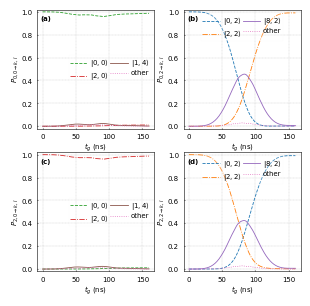

In [23]:
col_00 = ["tg"] + [r"$|0,0\rangle$", r"$|2,0\rangle$", r"$|1,4\rangle$"] + ["other"]
col_02 = ["tg"] + [r"$|0,2\rangle$", r"$|2,2\rangle$", r"$|8,2\rangle$"] + ["other"]
col_20 = ["tg"] + [r"$|0,0\rangle$", r"$|2,0\rangle$", r"$|1,4\rangle$"] + ["other"]
col_22 = ["tg"] + [r"$|0,2\rangle$", r"$|2,2\rangle$", r"$|8,2\rangle$"] + ["other"]
col_vec = [col_00, col_02, col_20, col_22]

color_00 = [colors[2], colors[3], colors[5], colors[6]]
color_01 = [colors[0], colors[1], colors[4], colors[6]]
color_10 = [colors[2], colors[3], colors[5], colors[6]]
color_11 = [colors[0], colors[1], colors[4], colors[6]]
color_vec = [color_00, color_01, color_10, color_11]
lstyle = [    "--",    "-.",    "-",    ":",]
ylabel_vec = [  r"$P_{0,0 \rightarrow k,l}$", r"$P_{0,2 \rightarrow k,l}$",
                r"$P_{2,0 \rightarrow k,l}$", r"$P_{2,2 \rightarrow k,l}$"]
order = ["(a)", "(b)", "(c)", "(d)"]

logi_state_one = [0, 2]
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(3.4, 3.4))
plt.subplots_adjust(wspace=0.25, hspace=0.2)
for i, state_i in enumerate(logi_state_one):
    for j, state_j in enumerate(logi_state_one):
        pop_ij = pd.read_csv(
            f"data/cnot_population_tg=160_{state_i}{state_j}_3ncut.txt"
        ).to_numpy()[:, :5]
        for k in np.arange(1, pop_ij.shape[1]):
            ax[i][j].plot( pop_ij[:, 0], gaussian_filter(pop_ij[:, k], 3), label=col_vec[2 * i + j][k],
                            color=color_vec[2 * i + j][k - 1], ls=lstyle[k - 1], lw=linewidth * 1.5, )
        ax[i][j].set_ylim(-0.02, 1.02)
        legend = ax[i][j].legend( ncol=2, loc="upper center", columnspacing=0.2,
            fontsize=Fontsize_legend, frameon=True, handlelength=2.5, handletextpad=0.4,
            handleheight=0.01, borderpad=0.2, framealpha=0.2, labelspacing=0.2, )
        legend.get_frame().set_linewidth(0.1)
        ax[i][j].grid(linewidth=0.2, linestyle="--")
        ax[i][j].set_xlabel(r"$t_g$ (ns)", labelpad=1)
        ax[i][j].set_ylabel(ylabel_vec[2 * i + j], labelpad=1)
        ax[i][j].text(
            0.03, 0.95, order[2 * i + j], transform=ax[i][j].transAxes, weight='bold', va="top"
        )
    legend = ax[i][0].legend( ncol=2, loc="center right", columnspacing=0.2,
        fontsize=Fontsize_legend, frameon=True, handlelength=2.5, handletextpad=0.4,
        handleheight=0.01, borderpad=0.2, framealpha=0.2, labelspacing=0.2, )
    legend.get_frame().set_linewidth(0.1)
plt.savefig("pdf_before_inkscape/cnot_population_tg=160.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

# Fidelity

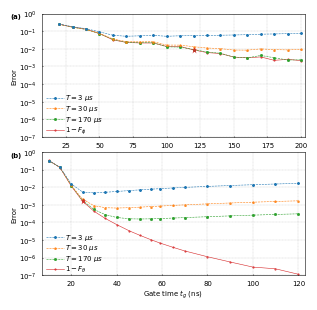

In [28]:
fig, ax = plt.subplots(figsize=(3.4, 3.4), nrows=2, gridspec_kw={"height_ratios": [1, 1]})
fig.subplots_adjust(hspace=0.12)
ax[0].plot(f_phi["tg"], 10 ** f_phi["f_500"], ".-", color=colors[3], label=r"$1-F_{\phi}$", ms=ms,)
ax[0].plot(f_phi["tg"], 10 ** f_phi["f_truc140_170us"], "s--", color=colors[2], label=r"$T = 170\ \mu s$", ms=ms,)
ax[0].plot(f_phi["tg"], 10 ** f_phi["f_truc140_30us"], "^--", color=colors[1], label=r"$T = 30\ \mu s$", ms=ms,)
ax[0].plot(f_phi["tg"], 10 ** f_phi["f_truc140_3us"], "D--", color=colors[0], label=r"$T = 3\ \mu s$", ms=ms,)
ax[0].plot(120.005, 10 ** (-2.06302516), "*", ms=5, markerfacecolor=colors[3], markeredgecolor="none",)

ax[1].plot(f_theta["tg"], 10 ** f_theta["f_500"], ".-", color=colors[3], label=r"$1-F_{\theta}$", ms=ms)
ax[1].plot(f_theta["tg"], 10 ** f_theta["f_170us_78"], "s--", color=colors[2], label=r"$T = 170\ \mu s$", ms=ms,)
ax[1].plot(f_theta["tg"], 10 ** f_theta["f_30us_78"], "^--", color=colors[1], label=r"$T = 30\ \mu s$", ms=ms)
ax[1].plot(f_theta["tg"], 10 ** f_theta["f_3us_78"], "D--", color=colors[0], label=r"$T = 3\ \mu s$", ms=ms)
ax[1].plot(25.020473, 10 ** (-2.79402547), "*", ms=5, markerfacecolor=colors[3], markeredgecolor="none",)
ax[0].set_xlim(7, 203)
ax[1].set_xlim(7, 123)

plt.xlabel("Gate time $t_g$ (ns)", labelpad=1)
for i in range(2):
    ax[i].text(-0.12, 1.0, order[i], transform=ax[i].transAxes, weight='bold', va="top")
    ax[i].set_yscale("log")
    ax[i].set_ylim(1e-7, 1e0)
    ax[i].set_yticks([1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    ax[i].set_ylabel("Error", labelpad=1)
    ax[i].grid(linewidth=0.2, linestyle="--",)
    handles0, labels0 = ax[i].get_legend_handles_labels()
    legend = ax[i].legend(handles0[::-1], labels0[::-1],
        loc="lower left",
        fontsize=Fontsize_legend,
        frameon=False,
        handlelength=2.5,
        handletextpad=0.2,
        handleheight=0.01,
        borderpad=0.2,
        labelspacing=0.1,  # Reduce the space between legend labels (adjust this value)
        bbox_to_anchor=(0, -0.03),  # Move the legend closer to the figure frame
    )
    legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.savefig("pdf_before_inkscape/xgate_fidelity.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

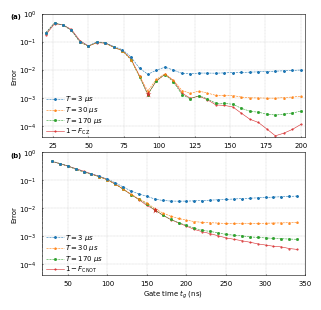

In [ ]:
fig, ax = plt.subplots( figsize=(3.4, 3.4), nrows=2, gridspec_kw={"height_ratios": [1, 1]})
fig.subplots_adjust(hspace=0.12)
# ax[0].plot(cz["tg"], 10 ** cz["f_1000_False"], "-", color=colors[0], label=r"$1-F_{\rm CZ}$")
ax[0].plot(cz_se["tg"], 10 ** cz_se["f_1000_False"], ".-", color=colors[3], label=r"$1-F_{\rm CZ}$", ms=ms,)
ax[0].plot(cz_se["tg"], 10 ** cz_se["f_truc55_170us"], "s--", color=colors[2], label=r"$T = 170\ \mu s$", ms=ms,)
ax[0].plot(cz_se["tg"], 10 ** cz_se["f_truc55_30us"], "^--", color=colors[1], label=r"$T = 30\ \mu s$", ms=ms,)
ax[0].plot(cz_se["tg"], 10 ** cz_se["f_truc55_3us"], "D--", color=colors[0], label=r"$T = 3\ \mu s$", ms=ms,)
ax[0].plot(91.950393, 10 ** (-2.87537611), "*", ms=5, markerfacecolor=colors[3], markeredgecolor="none",)

ax[1].plot(cnot["tg"], 10 ** cnot["f_1000_False"], ".-", color=colors[3], label=r"$1-F_{\rm CNOT}$", ms=ms)
ax[1].plot(cnot["tg"], 10 ** cnot["f_truc110_170us"], "s--", color=colors[2], label=r"$T = 170\ \mu s$", ms=ms)
ax[1].plot(cnot["tg"], 10 ** cnot["f_truc110_30us"], "^--", color=colors[1], label=r"$T = 30\ \mu s$", ms=ms)
ax[1].plot(cnot["tg"], 10 ** cnot["f_truc110_3us"], "D--", color=colors[0], label=r"$T = 3\ \mu s$", ms=ms)
ax[1].plot(160.000133, 10 ** (-2.05780752), "*", ms=5, markerfacecolor=colors[3], markeredgecolor="none",)

ax[0].set_xlim(17, 203)
ax[1].set_xlim(17, 350)
plt.xlabel("Gate time $t_g$ (ns)", labelpad=1)
for i in range(2):
    ax[i].text(-0.12, 1.0, order[i], transform=ax[i].transAxes, weight='bold', va="top")
    ax[i].set_yscale("log")
    ax[i].set_ylim(4e-5, 1e0)
    ax[i].set_yticks([1e-4, 1e-3, 1e-2, 1e-1, 1e0])
    ax[i].set_ylabel("Error", labelpad=1)
    ax[i].grid(linewidth=0.2, linestyle="--",)
    handles0, labels0 = ax[i].get_legend_handles_labels()
    legend = ax[i].legend(handles0[::-1], labels0[::-1],
        loc="lower left",
        fontsize=Fontsize_legend,
        frameon=False,
        handlelength=2.5,
        handletextpad=0.2,
        handleheight=0.01,
        borderpad=0.2,
        labelspacing=0.1,  # Reduce the space between legend labels (adjust this value)
        bbox_to_anchor=(0, -0.03),  # Move the legend closer to the figure frame
    )
    legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
plt.savefig("pdf_before_inkscape/2q_gate_fidelity.pdf", dpi=300, bbox_inches="tight", pad_inches = 0.02,)

# Pulse parameters

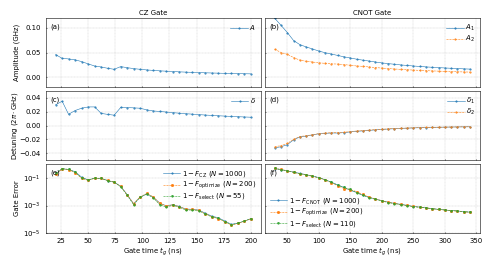

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(5.6, 2.8), gridspec_kw={"height_ratios": [2, 2, 2]}, )
fig.subplots_adjust(hspace=0.05, wspace=0.02)
# --- Left column: CZ ---
# ax[0, 0].plot(cz["tg"], cz["drive_amp"], ".-", label=r"$A$", ms=ms)
# ax[1, 0].plot(cz["tg"], cz["detune"], ".-", label=r"$\delta$", ms=ms)
# ax[2, 0].plot(cz["tg"], 10 ** cz["f_1000_False"], "-", label=r"$1-F_{\rm CZ}$ (N=1000)", ms=ms)
# ax[2, 0].plot(cz["tg"], 10 ** cz["f_200_select"], "--", label=r"$1-F_{\rm optimize}$ (N=200)", ms=ms)

ax[0, 0].plot(cz_se["tg"], cz_se["drive_amp"], ".-", label=r"$A$", ms=ms)
ax[1, 0].plot(cz_se["tg"], cz_se["detune"], ".-", label=r"$\delta$", ms=ms)
ax[2, 0].plot(cz_se["tg"], 10 ** cz_se["f_1000_False"], ".-", label=r"$1-F_{\rm CZ}\ (N=1000)$", ms=ms)
ax[2, 0].plot(cz_se["tg"], 10 ** cz_se["f_200_select"], "s--", label=r"$1-F_{\rm optimize}\ (N=200)$", ms=ms)
ax[2, 0].plot(cz_se["tg"], 10 ** cz_se["f_truc55_ideal"], "v--", label=r"$1-F_{\rm select}\ (N=55)$", ms=ms)
# ax[2, 0].plot(91.950393, 10 ** (-2.87537611), "*", ms=5, markerfacecolor=colors[0], markeredgecolor="none")

# --- Right column: CNOT ---
ax[0, 1].plot(cnot["tg"], cnot["drive_amp_1"], ".-", label=r"$A_1$", ms=ms)
ax[0, 1].plot(cnot["tg"], cnot["drive_amp_2"], ".--", label=r"$A_2$", ms=ms)
ax[1, 1].plot(cnot["tg"], cnot["detune_1"], ".-", label=r"$\delta_1$", ms=ms)
ax[1, 1].plot(cnot["tg"], cnot["detune_2"], ".--", label=r"$\delta_2$", ms=ms)
ax[2, 1].plot(cnot["tg"], 10 ** cnot["f_1000_False"], ".-", label=r"$1-F_{\rm CNOT}\ (N=1000)$", ms=ms)
ax[2, 1].plot(cnot["tg"], 10 ** cnot["f_200_select"], "s--", label=r"$1-F_{\rm optimize}\ (N=200)$", ms=ms)
ax[2, 1].plot(cnot["tg"], 10 ** cnot["f_truc110_ideal"], "v--", label=r"$1-F_{\rm select}\ (N=110)$", ms=ms)
# ax[2, 1].plot(160.000133, 10 ** (-2.05780752), "*", ms=5, markerfacecolor=colors[0], markeredgecolor="none")

# --- Formatting ---
labels = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"]]
titles = ["CZ Gate", "CNOT Gate"]
ylabs = ["Amplitude (GHz)", "Detuning ($2\pi\\cdot$GHz)", "Gate Error"]
ylims = [(-0.02, 0.12), (-0.05, 0.05), (1e-5, 1e0)]

for i in range(3):
    for j in range(2):
        ax[i, j].grid(linewidth=0.2, linestyle="--")
        ax[i, j].set_ylim(*ylims[i])
        ax[i, j].text(0.02, 0.92, labels[i][j], transform=ax[i, j].transAxes,
                      fontsize=Fontsize_legend, va="top", ha="left")
        if i < 2:
            ax[i, j].set_xticklabels([])
        else:
            ax[i, j].set_xlabel("Gate time $t_g$ (ns)", labelpad=1)

        legend = ax[i, j].legend(
            loc="best", fontsize=Fontsize_legend,
            frameon=False, handlelength=2.5, handletextpad=0.2,
            handleheight=0.01, borderpad=0.2, labelspacing=0.1,
        )
        legend.get_frame().set_alpha(0.2)

    # Y-axis labels aligned only on the left column
    ax[i, 0].set_ylabel(ylabs[i], labelpad=1)  # Increase value for more left shift
    ax[i, 0].yaxis.set_label_coords(-0.12, 0.5)  # Adjust -0.22 as needed    
    ax[i, 1].tick_params(labelleft=False)
# Set column titles
for j in range(2):
    ax[0, j].set_title(titles[j], pad=2)
    ax[2, j].set_yscale("log")
    ax[j, 0].set_xticklabels([])
    ax[j, 1].set_xticklabels([])    
# Save figure
plt.savefig("pdf_before_inkscape/params_2q.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)